# 🎯 音频分类推理脚本

本 Notebook 用于加载训练好的模型进行推理，支持以下功能：
- 选择不同的前端（Frontend）类型
- 加载对应的预训练模型权重
- 在测试数据集上进行推理
- 输出混淆矩阵、分类报告、特征可视化等结果

---

## 支持的前端类型

| 前端名称 | 描述 | 模型权重 |
|---------|------|----------|
| `fft` | Log-Magnitude FFT 频谱 | `fft_best.weights.h5` |
| `logmel` | Log-Mel 频谱图 | `logmel_best.weights.h5` |
| `pcen` | PCEN (Per-Channel Energy Normalization) | `pcen_best.weights.h5` |
| `mfcc` | MFCC (Mel-Frequency Cepstral Coefficients) | `mfcc_best.weights.h5` |
| `logmel_wiener` | Log-Mel + Wiener 降噪 | `logmel_wiener_best.weights.h5` |
| `pcen_wiener` | PCEN + Wiener 降噪 | `pcen_wiener_real_bias_best.weights.h5` |

## 1. 导入依赖

In [261]:
# ===== Bootstrap for static checkers (basedpyright) =====
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from IPython.display import display, Audio

# 如果这些是在后面 cell 才会赋值，先给占位（让静态检查器闭嘴）
FRONTEND_TYPE: str = "fft"
NUM_CLASSES: int = 0
class_names: np.ndarray | list[str] = []

y_test: np.ndarray
y_pred: np.ndarray
y_pred_proba: np.ndarray
X_test_features: np.ndarray
X_test_paths: np.ndarray


In [262]:
import os
import sys
import numpy as np
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib
from IPython.display import display, Audio
import warnings
warnings.filterwarnings('ignore')

import numpy as np

# 添加 src 目录到 path
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from model import build_model
from model_config import (
    MODEL_KWARGS,
    FRONTEND_TYPES,
    SPEC_SUB_FRONTENDS,
    WIENER_FRONTENDS,
    get_input_shape,
    get_model_weights_path,
    DEFAULT_CALIB_NOISE_WAV,
    SAMPLE_RATE, DURATION, TARGET_LEN,
    N_FFT, HOP_LENGTH, CENTER,
    N_MELS, N_MFCC, FMIN, FMAX, TOP_DB,
    MAX_FRAMES, N_BINS,
    PCEN_KWARGS, SPEC_SUB_PARAMS,
)

# GPU 配置
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU 已就绪: {len(gpus)} 个设备")
else:
    print("⚠️ 未检测到 GPU，使用 CPU 推理")

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# 类型提示：FRONTEND_TYPE 将在后续单元格中定义
from typing import TYPE_CHECKING
if TYPE_CHECKING:
    FRONTEND_TYPE: str

⚠️ 未检测到 GPU，使用 CPU 推理


## 2. ⚙️ 配置区域

### 2.1 设置测试数据集路径

In [263]:
# =============================================================================
# 🎛️ 测试数据集路径配置
# =============================================================================
# 测试数据集目录 (testset目录包含emergency, movement, unknown三个子目录)
TEST_DATA_DIR = "/Users/zilongzeng/Research/Drone/testset"

# 如果使用已处理好的数据路径文件 (npz):
PROCESSED_DATA_PATH = "../dataset/processed/data_paths.npz"

# Label Encoder 路径
ENCODER_PATH = "../saved_models/label_encoder.joblib"

# 是否使用 npz 还是从testset目录扫描
USE_PROCESSED_DATA = False  # True: 使用 npz; False: 从testset目录扫描

### 2.2 选择前端类型和模型

In [264]:
# =============================================================================
# 🎛️ 前端类型选择
# =============================================================================
FRONTEND_TYPE = "mfcc_wiener"  # 可选: fft, logmel, pcen, mfcc, fft_specsub, logmel_specsub, pcen_specsub, mfcc_specsub, fft_wiener, logmel_wiener, pcen_wiener, mfcc_wiener

# =============================================================================
# 🎛️ 模型权重路径 (自动选择，可手动覆盖)
# =============================================================================
MODEL_WEIGHTS_PATH = None
MODEL_WEIGHTS_BASE = "../saved_models"

if MODEL_WEIGHTS_PATH is None:
    MODEL_WEIGHTS_PATH = get_model_weights_path(FRONTEND_TYPE, base_dir=MODEL_WEIGHTS_BASE)

print(f"📌 前端类型: {FRONTEND_TYPE}")
print(f"📌 模型权重: {MODEL_WEIGHTS_PATH}")


📌 前端类型: mfcc_wiener
📌 模型权重: ../saved_models/mfcc_wiener/mfcc_wiener_best.weights.h5


### 2.3 噪声配置（Wiener 前端需要）

In [265]:
# =============================================================================
# 🎛️ Wiener 降噪配置（wiener 前端）
# =============================================================================
CALIB_NOISE_WAV = os.path.join("..", DEFAULT_CALIB_NOISE_WAV)
ENABLE_WIENER_DENOISE = FRONTEND_TYPE in WIENER_FRONTENDS

if ENABLE_WIENER_DENOISE:
    print(f"📌 Wiener 降噪已启用，校准噪声: {CALIB_NOISE_WAV}")
else:
    print("📌 Wiener 降噪未启用")


📌 Wiener 降噪已启用，校准噪声: /Users/zilongzeng/Research/DroneControl/tellonoise/20251029_190227.wav


## 3. 定义前端和特征提取函数

In [266]:
# =============================================================================
# 音频/前端参数（统一来自 model_config）
# =============================================================================
print(f"📌 SAMPLE_RATE={SAMPLE_RATE}, DURATION={DURATION}, MAX_FRAMES={MAX_FRAMES}")


📌 SAMPLE_RATE=16000, DURATION=1.0, MAX_FRAMES=32


In [267]:
# =============================================================================
# Wiener 降噪相关函数
# =============================================================================
NOISE_PROFILE_BASE = None

def build_noise_profile_from_wav(wav_path, seconds=1.0, method="mean"):
    """从校准噪声文件构建噪声功率谱 profile"""
    ns, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
    target = int(seconds * SAMPLE_RATE)
    
    if len(ns) < target:
        ns = np.pad(ns, (0, target - len(ns)), mode="wrap")
    else:
        ns = ns[:target]
    
    N = librosa.stft(ns, n_fft=N_FFT, hop_length=HOP_LENGTH, center=CENTER)
    Pn = (np.abs(N) ** 2).astype(np.float32)
    
    if method == "median":
        profile = np.median(Pn, axis=1)
    else:
        profile = np.mean(Pn, axis=1)
    
    return profile.astype(np.float32)

def wiener_denoise_with_profile(y_mix, noise_profile, eps=1e-12):
    """使用固定噪声 profile 的 Wiener 滤波"""
    X = librosa.stft(y_mix, n_fft=N_FFT, hop_length=HOP_LENGTH, center=CENTER)
    Px = (np.abs(X) ** 2).astype(np.float32)
    
    Pn = noise_profile.astype(np.float32)[:, None]
    
    if Pn.shape[0] != Px.shape[0]:
        m = min(Pn.shape[0], Px.shape[0])
        Pn = Pn[:m, :]
        Px = Px[:m, :]
        X = X[:m, :]
    
    Ps = np.maximum(Px - Pn, 0.0)
    G = Ps / (Ps + Pn + eps)
    Y = G * X
    
    y_out = librosa.istft(Y, hop_length=HOP_LENGTH, center=CENTER, length=len(y_mix))
    return y_out.astype(np.float32)

# 如果启用 Wiener，构建噪声 profile
if ENABLE_WIENER_DENOISE and os.path.exists(CALIB_NOISE_WAV):
    NOISE_PROFILE_BASE = build_noise_profile_from_wav(CALIB_NOISE_WAV, seconds=1.0)
    print(f"✅ 噪声 profile 已构建: shape={NOISE_PROFILE_BASE.shape}")
elif ENABLE_WIENER_DENOISE:
    print(f"⚠️ 校准噪声文件不存在: {CALIB_NOISE_WAV}")

✅ 噪声 profile 已构建: shape=(513,)


In [268]:
# =============================================================================
# 特征提取函数
# =============================================================================

def spectral_subtract(
    y_mix,
    n_fft,
    hop_length,
    center=False,
    alpha=1.0,
    floor=1e-6,
    noise_est_percentile=0.2,
):
    X = librosa.stft(y_mix, n_fft=n_fft, hop_length=hop_length, center=center)
    mag_X = np.abs(X)

    frame_energy = np.mean(mag_X, axis=0)
    k = max(1, int(len(frame_energy) * noise_est_percentile))
    idx = np.argsort(frame_energy)[:k]
    noise_mag = np.mean(mag_X[:, idx], axis=1, keepdims=True)

    mag_sub = np.maximum(mag_X - alpha * noise_mag, floor)
    Y = mag_sub * np.exp(1j * np.angle(X))
    y_out = librosa.istft(Y, hop_length=hop_length, center=center, length=len(y_mix))
    return y_out.astype(np.float32)


def extract_fft_features(y):
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, center=CENTER)
    mag = np.abs(D).astype(np.float32)
    feat = librosa.amplitude_to_db(mag, ref=np.max, top_db=TOP_DB)

    if feat.shape[1] < MAX_FRAMES:
        feat = np.pad(feat, ((0, 0), (0, MAX_FRAMES - feat.shape[1])), mode='constant')
    else:
        feat = feat[:, :MAX_FRAMES]
    return feat.astype(np.float32)


def extract_logmel_features(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE,
        n_fft=N_FFT, hop_length=HOP_LENGTH, center=CENTER,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )
    feat = librosa.power_to_db(mel, ref=np.max, top_db=TOP_DB)

    if feat.shape[1] < MAX_FRAMES:
        feat = np.pad(feat, ((0, 0), (0, MAX_FRAMES - feat.shape[1])), mode='constant')
    else:
        feat = feat[:, :MAX_FRAMES]
    return feat.astype(np.float32)


def extract_pcen_features(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE,
        n_fft=N_FFT, hop_length=HOP_LENGTH, center=CENTER,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )
    feat = librosa.pcen(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, **PCEN_KWARGS)

    if feat.shape[1] < MAX_FRAMES:
        feat = np.pad(feat, ((0, 0), (0, MAX_FRAMES - feat.shape[1])), mode='constant')
    else:
        feat = feat[:, :MAX_FRAMES]
    return feat.astype(np.float32)


def extract_mfcc_features(y):
    mfcc = librosa.feature.mfcc(
        y=y, sr=SAMPLE_RATE,
        n_mfcc=N_MFCC, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, center=CENTER,
        fmin=FMIN, fmax=FMAX
    )

    if mfcc.shape[1] < MAX_FRAMES:
        mfcc = np.pad(mfcc, ((0, 0), (0, MAX_FRAMES - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :MAX_FRAMES]
    return mfcc.astype(np.float32)


def extract_features(y, frontend_type, apply_wiener=False):
    if frontend_type in SPEC_SUB_FRONTENDS:
        y = spectral_subtract(
            y,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            center=CENTER,
            **SPEC_SUB_PARAMS,
        )

    if apply_wiener and NOISE_PROFILE_BASE is not None:
        y = wiener_denoise_with_profile(y, NOISE_PROFILE_BASE)

    if frontend_type in {"fft", "fft_specsub", "fft_wiener"}:
        return extract_fft_features(y)
    if frontend_type in {"logmel", "logmel_specsub", "logmel_wiener"}:
        return extract_logmel_features(y)
    if frontend_type in {"pcen", "pcen_specsub", "pcen_wiener"}:
        return extract_pcen_features(y)
    if frontend_type in {"mfcc", "mfcc_specsub", "mfcc_wiener"}:
        return extract_mfcc_features(y)

    raise ValueError(f"未知的前端类型: {frontend_type}")


print("✅ 特征提取函数已定义")


✅ 特征提取函数已定义


## 4. 加载数据

In [269]:
# =============================================================================
# 加载标签编码器
# =============================================================================
le = joblib.load(ENCODER_PATH)
class_names = le.classes_
NUM_CLASSES = len(class_names)

print(f"✅ 标签编码器已加载")
print(f"📌 类别数量: {NUM_CLASSES}")
print(f"📌 类别名称: {list(class_names)}")

✅ 标签编码器已加载
📌 类别数量: 3
📌 类别名称: [np.str_('emergency'), np.str_('movement'), np.str_('unknown')]


In [270]:
# =============================================================================
# 加载测试数据
# =============================================================================
if USE_PROCESSED_DATA:
    # 从 npz 文件加载
    data = np.load(PROCESSED_DATA_PATH, allow_pickle=True)
    X_test_paths = data['X_test']
    y_test = data['y_test']
    print(f"✅ 从 {PROCESSED_DATA_PATH} 加载测试数据")
else:
    # 从testset目录扫描 (目录结构: testset/emergency/, testset/movement/, testset/unknown/)
    X_test_paths = []
    y_test = []
    
    # 检查testset目录是否存在
    if not os.path.isdir(TEST_DATA_DIR):
        raise ValueError(f"测试数据目录不存在: {TEST_DATA_DIR}")
    
    print(f"📂 扫描测试数据目录: {TEST_DATA_DIR}")
    
    # 遍历testset目录下的所有子目录
    for item in os.listdir(TEST_DATA_DIR):
        item_path = os.path.join(TEST_DATA_DIR, item)
        
        # 如果是目录，检查是否是已知的类别
        if os.path.isdir(item_path):
            # 检查类别名称是否在标签编码器中
            if item in class_names:
                class_idx = le.transform([item])[0]
                count = 0
                
                # 递归遍历该目录下的所有wav文件
                for root, _, files in os.walk(item_path):
                    for f in files:
                        if f.lower().endswith('.wav'):
                            X_test_paths.append(os.path.join(root, f))
                            y_test.append(class_idx)
                            count += 1
                
                print(f"   - {item}: {count} 个样本")
            else:
                print(f"   ⚠️ 跳过未知类别目录: {item}")
    
    X_test_paths = np.array(X_test_paths)
    y_test = np.array(y_test)
    print(f"✅ 从 {TEST_DATA_DIR} 扫描测试数据完成")

print(f"📌 测试样本总数: {len(X_test_paths)}")

# 显示每个类别的样本数
if len(y_test) > 0:
    unique, counts = np.unique(y_test, return_counts=True)
    for cls_idx, cnt in zip(unique, counts):
        print(f"   - {class_names[cls_idx]}: {cnt} 样本")
else:
    print("⚠️ 警告: 未找到任何测试样本！")

📂 扫描测试数据目录: /Users/zilongzeng/Research/Drone/testset
   - emergency: 307 个样本
   - movement: 326 个样本
   - unknown: 231 个样本
✅ 从 /Users/zilongzeng/Research/Drone/testset 扫描测试数据完成
📌 测试样本总数: 864
   - emergency: 307 样本
   - movement: 326 样本
   - unknown: 231 样本


## 5. 加载模型

In [271]:
# =============================================================================
# 构建并加载模型
# =============================================================================
print(f">>> 构建模型...")
# 获取输入形状
INPUT_SHAPE = get_input_shape(FRONTEND_TYPE)
print(f"📌 输入形状: {INPUT_SHAPE}")
print(f"📌 输出类别: {NUM_CLASSES}")

model = build_model(INPUT_SHAPE, NUM_CLASSES, **MODEL_KWARGS)

# 加载权重
print(f">>> 加载权重: {MODEL_WEIGHTS_PATH}")
model.load_weights(MODEL_WEIGHTS_PATH)

print("✅ 模型加载成功")
model.summary()

>>> 构建模型...
📌 输入形状: (40, 32, 1)
📌 输出类别: 3
>>> 加载权重: ../saved_models/mfcc_wiener/mfcc_wiener_best.weights.h5
✅ 模型加载成功


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 40, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 40, 32,    │        640 │ input_layer_13[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 32,    │        256 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 40, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_39    │ (None, 10, 32,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 10, 32,    │     36,928 │ max_pooling2d_39… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 32,    │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_40       │ (None, 10, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_40    │ (None, 2, 32, 64) │          0 │ activation_40[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 2, 32, 64) │     36,928 │ max_pooling2d_40… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 32, 64) │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_41       │ (None, 2, 32, 64) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_41    │ (None, 1, 32, 64) │          0 │ activation_41[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_13          │ (None, 32, 1, 64) │          0 │ max_pooling2d_41… │
│ (Permute)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_13          │ (None, 32, 64)    │          0 │ permute_13[0][0]  │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchformer0_ff1_… │ (None, 32, 256)   │     16,640 │ reshape_13[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchformer0_ff1_… │ (None, 32, 256)   │          0 │ branchformer0_ff… │
│ (Dropout)           │                   │            │                 

 Total params: 198,659 (776.01 KB)

 Trainable params: 198,147 (774.01 KB)

 Non-trainable params: 512 (2.00 KB)

## 6. 提取测试集特征

In [272]:
# =============================================================================
# 批量提取测试集特征
# =============================================================================
def load_audio(filepath, sr=SAMPLE_RATE, duration=DURATION):
    """加载并预处理音频"""
    try:
        audio, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
        target_len = int(duration * sr)
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        else:
            audio = audio[:target_len]
        return audio
    except Exception as e:
        print(f"⚠️ 加载失败: {filepath}, 错误: {e}")
        return np.zeros(int(duration * sr), dtype=np.float32)

print(f">>> 提取 {FRONTEND_TYPE} 特征...")
apply_wiener = FRONTEND_TYPE in WIENER_FRONTENDS

X_test_features = []
for i, filepath in enumerate(X_test_paths):
    if (i + 1) % 100 == 0:
        print(f"  处理进度: {i+1}/{len(X_test_paths)}")
    
    audio = load_audio(filepath)
    feat = extract_features(audio, FRONTEND_TYPE, apply_wiener=apply_wiener)
    X_test_features.append(feat)

X_test_features = np.array(X_test_features)
X_test_features = np.expand_dims(X_test_features, axis=-1)  # 添加通道维度

print(f"✅ 特征提取完成")
print(f"📌 特征形状: {X_test_features.shape}")

>>> 提取 mfcc_wiener 特征...
  处理进度: 100/864
  处理进度: 200/864
  处理进度: 300/864
  处理进度: 400/864
  处理进度: 500/864
  处理进度: 600/864
  处理进度: 700/864
  处理进度: 800/864
✅ 特征提取完成
📌 特征形状: (864, 40, 32, 1)


## 7. 推理与评估

In [273]:
# =============================================================================
# 模型推理
# =============================================================================
print(">>> 开始推理...")
y_pred_proba = model.predict(X_test_features, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ 推理完成")
print(f"📊 测试集准确率: {accuracy * 100:.2f}%")

>>> 开始推理...
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

✅ 推理完成
📊 测试集准确率: 60.88%


In [274]:
# =============================================================================
# 分类报告
# =============================================================================
print("\n" + "=" * 70)
print(f"📋 分类报告 - {FRONTEND_TYPE.upper()} 前端")
print("=" * 70)
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


📋 分类报告 - MFCC_WIENER 前端
              precision    recall  f1-score   support

   emergency       0.57      0.59      0.58       307
    movement       0.71      0.52      0.60       326
     unknown       0.58      0.76      0.66       231

    accuracy                           0.61       864
   macro avg       0.62      0.62      0.61       864
weighted avg       0.62      0.61      0.61       864



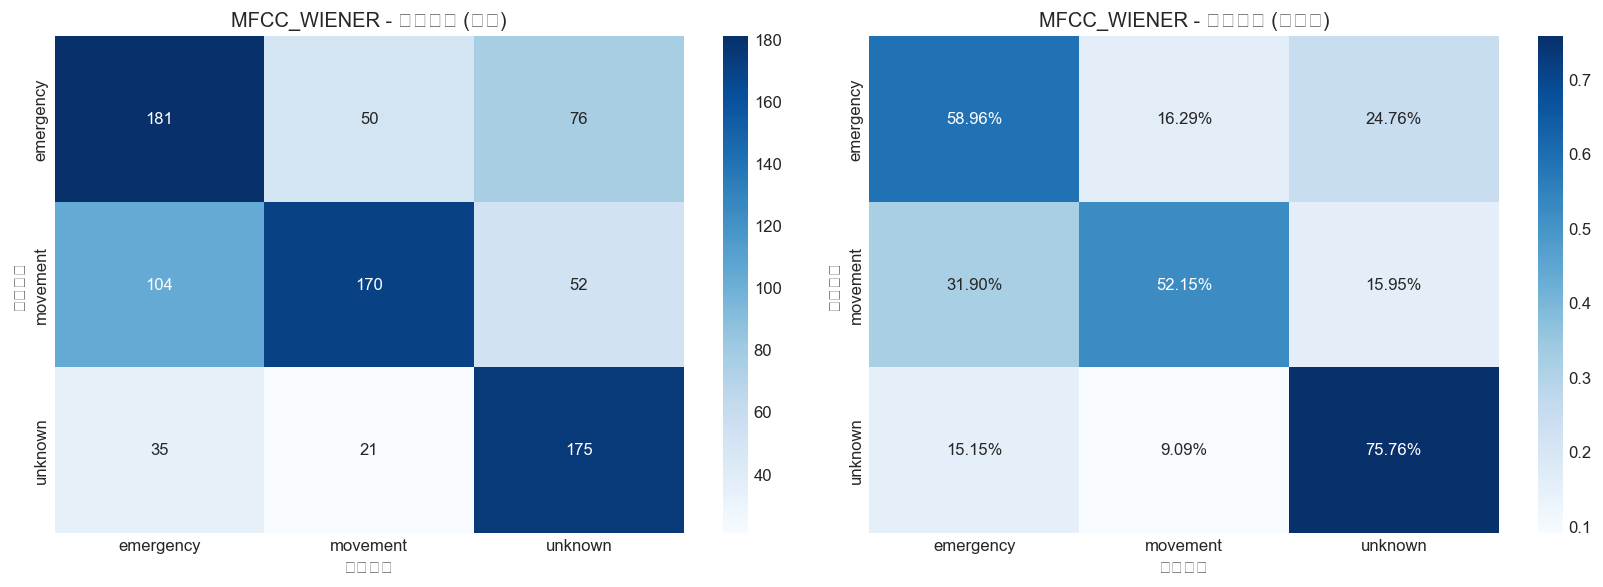

In [275]:
# =============================================================================
# 混淆矩阵可视化
# =============================================================================
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绝对数量混淆矩阵
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'{FRONTEND_TYPE.upper()} - 混淆矩阵 (数量)', fontsize=12)
axes[0].set_ylabel('真实标签')
axes[0].set_xlabel('预测标签')

# 归一化混淆矩阵 (按行归一化)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'{FRONTEND_TYPE.upper()} - 混淆矩阵 (归一化)', fontsize=12)
axes[1].set_ylabel('真实标签')
axes[1].set_xlabel('预测标签')

plt.tight_layout()
plt.show()

## 8. 特征可视化

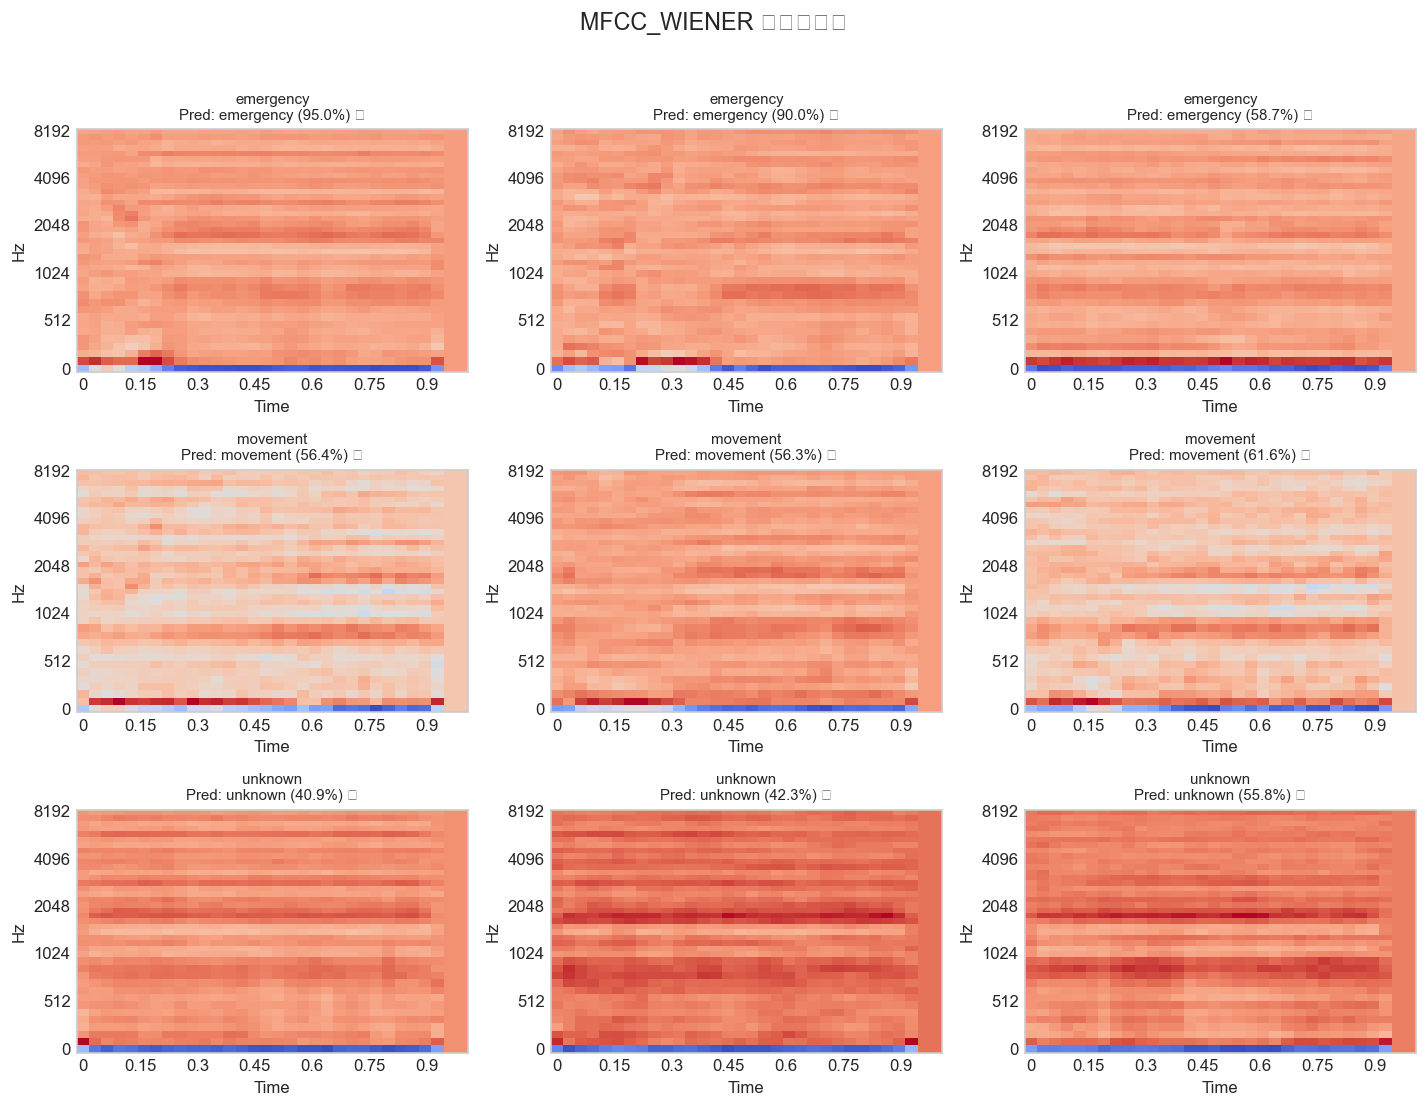

In [276]:
# =============================================================================
# 随机选择样本进行特征可视化
# =============================================================================
N_SAMPLES_TO_SHOW = 3  # 每个类别显示的样本数

fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES_TO_SHOW, figsize=(4 * N_SAMPLES_TO_SHOW, 3 * NUM_CLASSES))

for cls_idx, cls_name in enumerate(class_names):
    # 获取该类别的样本索引
    cls_indices = np.where(y_test == cls_idx)[0]
    sample_indices = np.random.choice(cls_indices, size=min(N_SAMPLES_TO_SHOW, len(cls_indices)), replace=False)
    
    for j, sample_idx in enumerate(sample_indices):
        ax = axes[cls_idx, j] if NUM_CLASSES > 1 else axes[j]
        
        feat = X_test_features[sample_idx, :, :, 0]
        
        # 根据前端类型选择 y 轴标签
        if FRONTEND_TYPE == "fft":
            y_axis = "linear"
        elif FRONTEND_TYPE == "mfcc":
            y_axis = None  # MFCC 没有对应的频率轴
        else:
            y_axis = "mel"
        
        if y_axis:
            librosa.display.specshow(feat, x_axis='time', y_axis=y_axis,
                                     sr=SAMPLE_RATE, hop_length=HOP_LENGTH, ax=ax)
        else:
            im = ax.imshow(feat, aspect='auto', origin='lower', cmap='viridis')
            ax.set_xlabel('Time Frame')
            ax.set_ylabel('MFCC Coefficient')
        
        # 预测结果
        pred_cls = class_names[y_pred[sample_idx]]
        pred_prob = y_pred_proba[sample_idx, y_pred[sample_idx]]
        is_correct = "✓" if y_pred[sample_idx] == cls_idx else "✗"
        
        ax.set_title(f'{cls_name}\nPred: {pred_cls} ({pred_prob:.1%}) {is_correct}', fontsize=9)

plt.suptitle(f'{FRONTEND_TYPE.upper()} 特征可视化', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. 单样本推理演示

In [277]:
# =============================================================================
# 🎛️ 单样本推理：修改下方路径测试单个音频文件
# =============================================================================
SINGLE_AUDIO_PATH = str(X_test_paths[0])  # 或手动指定路径

print(f">>> 单样本推理: {SINGLE_AUDIO_PATH}")

# 加载音频
audio = load_audio(SINGLE_AUDIO_PATH)

# 提取特征
apply_wiener = FRONTEND_TYPE in WIENER_FRONTENDS
feat = extract_features(audio, FRONTEND_TYPE, apply_wiener=apply_wiener)
feat_input = feat[np.newaxis, :, :, np.newaxis]  # 添加 batch 和 channel 维度

# 推理
proba = model.predict(feat_input, verbose=0)[0]
pred_idx = np.argmax(proba)
pred_class = class_names[pred_idx]
pred_conf = proba[pred_idx]

print(f"\n📊 预测结果:")
print(f"   类别: {pred_class}")
print(f"   置信度: {pred_conf:.2%}")
print(f"\n📊 各类别概率:")
for i, cls_name in enumerate(class_names):
    bar = "█" * int(proba[i] * 30)
    print(f"   {cls_name:12s}: {proba[i]:.2%} {bar}")

>>> 单样本推理: /Users/zilongzeng/Research/Drone/testset/emergency/Freeze/023_345753.wav

📊 预测结果:
   类别: unknown
   置信度: 53.26%

📊 各类别概率:
   emergency   : 14.13% ████
   movement    : 32.60% █████████
   unknown     : 53.26% ███████████████


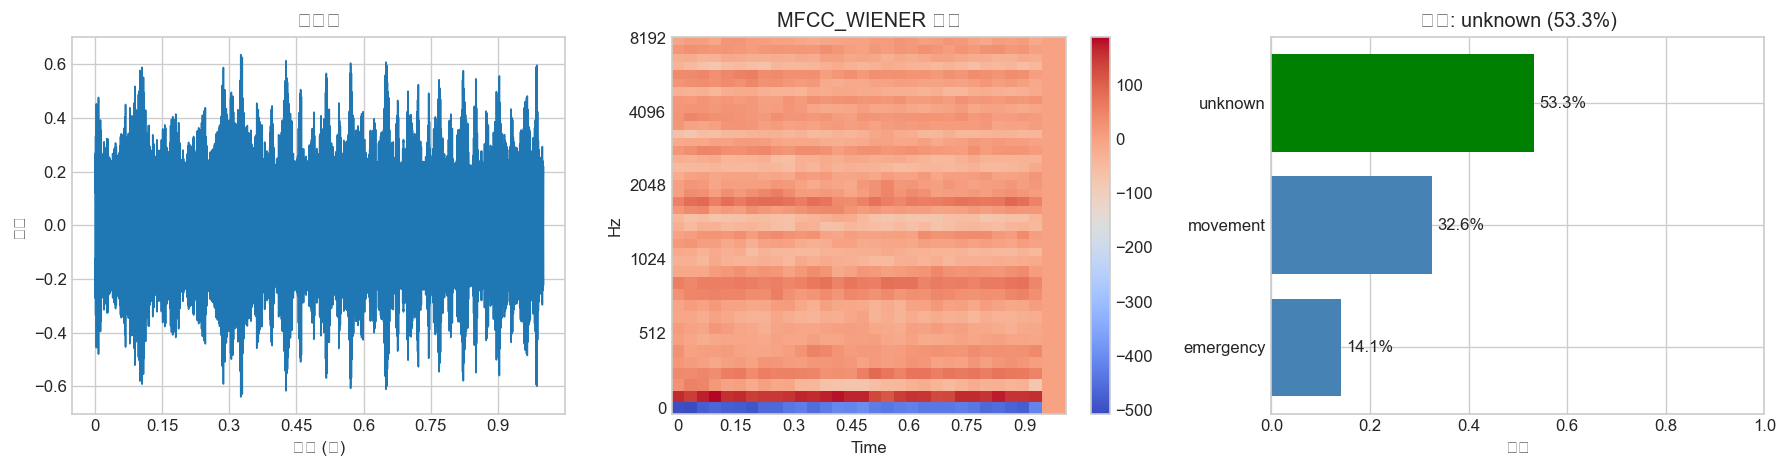


🔊 音频播放:


In [278]:
# =============================================================================
# 单样本可视化
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. 波形图
librosa.display.waveshow(audio, sr=SAMPLE_RATE, ax=axes[0])
axes[0].set_title('波形图')
axes[0].set_xlabel('时间 (秒)')
axes[0].set_ylabel('振幅')

# 2. 特征图
if FRONTEND_TYPE == "mfcc":
    im = axes[1].imshow(feat, aspect='auto', origin='lower', cmap='viridis')
    axes[1].set_xlabel('Time Frame')
    axes[1].set_ylabel('MFCC Coefficient')
else:
    y_axis = "linear" if FRONTEND_TYPE == "fft" else "mel"
    librosa.display.specshow(feat, x_axis='time', y_axis=y_axis,
                             sr=SAMPLE_RATE, hop_length=HOP_LENGTH, ax=axes[1])
axes[1].set_title(f'{FRONTEND_TYPE.upper()} 特征')
plt.colorbar(axes[1].collections[0] if FRONTEND_TYPE != "mfcc" else im, ax=axes[1])

# 3. 预测概率柱状图
colors = ['green' if i == pred_idx else 'steelblue' for i in range(NUM_CLASSES)]
bars = axes[2].barh(class_names, proba, color=colors)
axes[2].set_xlim(0, 1)
axes[2].set_xlabel('概率')
axes[2].set_title(f'预测: {pred_class} ({pred_conf:.1%})')
for bar, p in zip(bars, proba):
    axes[2].text(p + 0.01, bar.get_y() + bar.get_height()/2, f'{p:.1%}', va='center')

plt.tight_layout()
plt.show()

# 播放音频
print("\n🔊 音频播放:")
display(Audio(audio, rate=SAMPLE_RATE))

## 10. 错误分析

📊 错误预测数量: 338 / 864 (39.1%)


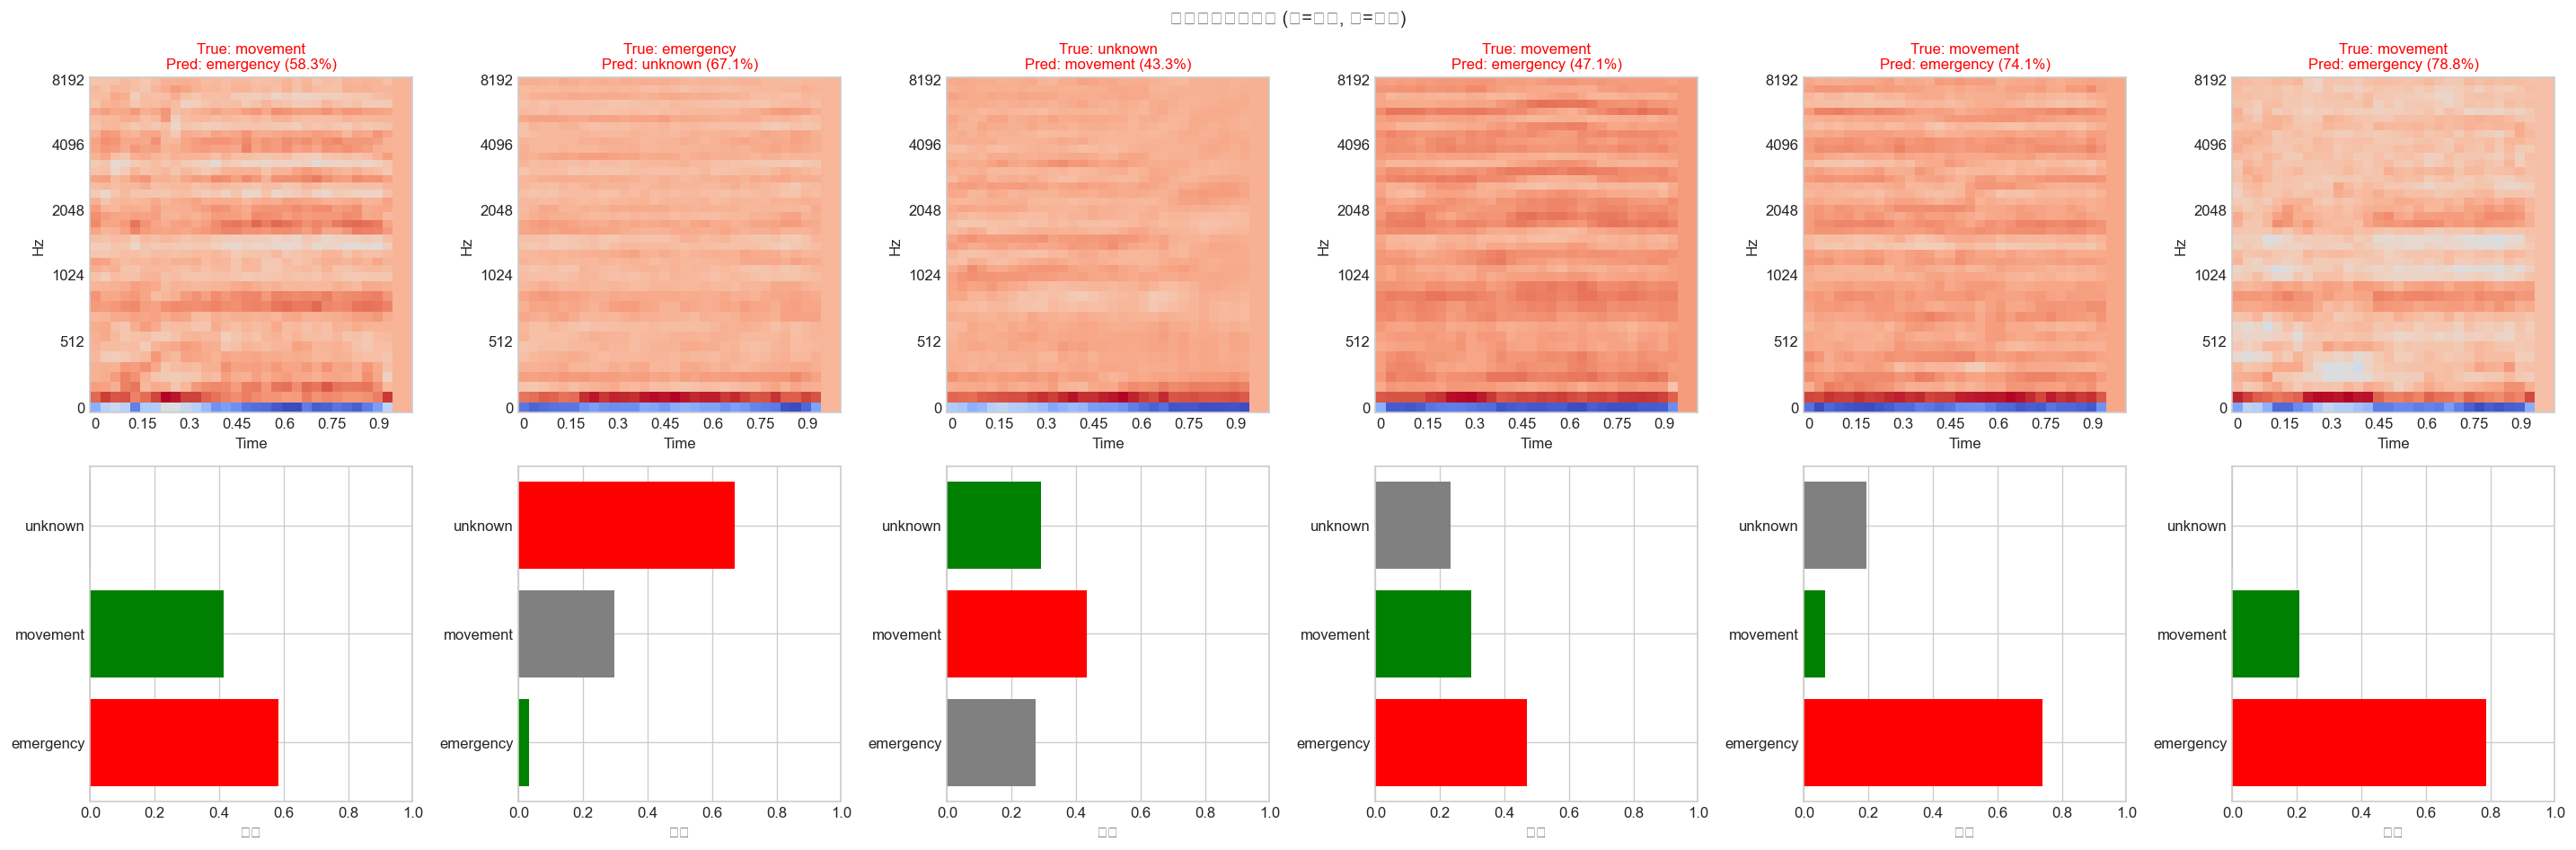

In [279]:
# =============================================================================
# 分析错误预测的样本
# =============================================================================
# 找出错误预测的索引
error_indices = np.where(y_pred != y_test)[0]
print(f"📊 错误预测数量: {len(error_indices)} / {len(y_test)} ({len(error_indices)/len(y_test)*100:.1f}%)")

if len(error_indices) > 0:
    # 显示部分错误样本
    N_ERRORS_TO_SHOW = min(6, len(error_indices))
    sample_errors = np.random.choice(error_indices, size=N_ERRORS_TO_SHOW, replace=False)
    
    fig, axes = plt.subplots(2, N_ERRORS_TO_SHOW, figsize=(4 * N_ERRORS_TO_SHOW, 8))
    
    for i, err_idx in enumerate(sample_errors):
        true_cls = class_names[y_test[err_idx]]
        pred_cls = class_names[y_pred[err_idx]]
        pred_conf = y_pred_proba[err_idx, y_pred[err_idx]]
        
        # 特征图
        feat = X_test_features[err_idx, :, :, 0]
        if FRONTEND_TYPE == "mfcc":
            axes[0, i].imshow(feat, aspect='auto', origin='lower', cmap='viridis')
        else:
            y_axis = "linear" if FRONTEND_TYPE == "fft" else "mel"
            librosa.display.specshow(feat, x_axis='time', y_axis=y_axis,
                                     sr=SAMPLE_RATE, hop_length=HOP_LENGTH, ax=axes[0, i])
        axes[0, i].set_title(f'True: {true_cls}\nPred: {pred_cls} ({pred_conf:.1%})', fontsize=10, color='red')
        
        # 概率分布
        proba = y_pred_proba[err_idx]
        colors = ['red' if j == y_pred[err_idx] else 'green' if j == y_test[err_idx] else 'gray' 
                  for j in range(NUM_CLASSES)]
        axes[1, i].barh(class_names, proba, color=colors)
        axes[1, i].set_xlim(0, 1)
        axes[1, i].set_xlabel('概率')
    
    plt.suptitle('错误预测样本分析 (红=预测, 绿=真实)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("🎉 没有错误预测！")

## 11. 保存结果

In [280]:
# =============================================================================
# 保存推理结果
# =============================================================================
SAVE_RESULTS = True  # 设为 True 保存结果
OUTPUT_DIR = f"../result/inference_{FRONTEND_TYPE}/"

if SAVE_RESULTS:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # 保存分类报告
    with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
        f.write(f"前端类型: {FRONTEND_TYPE}\n")
        f.write(f"模型权重: {MODEL_WEIGHTS_PATH}\n")
        f.write(f"测试样本: {len(y_test)}\n")
        f.write(f"准确率: {accuracy * 100:.2f}%\n\n")
        f.write(report)
    
    # 保存混淆矩阵图
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{FRONTEND_TYPE.upper()} - 混淆矩阵')
    ax.set_ylabel('真实标签')
    ax.set_xlabel('预测标签')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
    plt.close()
    
    # 保存预测结果
    np.savez(
        os.path.join(OUTPUT_DIR, "predictions.npz"),
        y_true=y_test,
        y_pred=y_pred,
        y_proba=y_pred_proba,
        filepaths=X_test_paths
    )
    
    print(f"✅ 结果已保存到: {OUTPUT_DIR}")
    print(f"   - classification_report.txt")
    print(f"   - confusion_matrix.png")
    print(f"   - predictions.npz")
else:
    print("📌 结果保存已跳过 (SAVE_RESULTS=False)")

✅ 结果已保存到: ../result/inference_mfcc_wiener/
   - classification_report.txt
   - confusion_matrix.png
   - predictions.npz


---

## 📌 使用说明

1. **选择前端类型**: 在 Cell 2.2 中修改 `FRONTEND_TYPE` 变量
2. **指定测试数据**: 在 Cell 2.1 中设置 `TEST_DATA_DIR` (默认: `/Users/zilongzeng/Research/Drone/testset`) 或设置 `USE_PROCESSED_DATA=True` 使用 npz 文件
3. **Wiener 配置**: 如果使用 `logmel_wiener` 或 `pcen_wiener`，确保 Cell 2.3 中的噪声文件路径正确
4. **运行所有 Cell**: 依次运行所有 Cell 进行推理和可视化
5. **保存结果**: 在 Cell 11 中设置 `SAVE_RESULTS=True` 保存推理结果

---